# Modeling KB_RF Nickels_Ethan

> **Objectif :** Entraîner et évaluer un modèle **Random Forest** sur la **sélection Select K-Best (Phase 3, section 4)** issue de la
> Phase 3, avec optimisation des hyperparamètres, validation croisée et analyse de l'overfitting.
>
> **Auteurs :** Nickels Ethan

---
## Table des matières
1. [Importation des librairies et des données](#section-1)
2. [Choix de l'indicateur de performance](#section-2)
3. [Optimisation des hyperparamètres (GridSearchCV)](#section-3)
4. [Évaluation sur le jeu de test](#section-4)
5. [Analyse de l'overfitting / underfitting](#section-5)
6. [Réflexion originale](#section-6)
7. [Questionnements pertinents](#section-7)
8. [Sauvegarde des résultats](#section-8)

---
## 1. Importation des librairies et des données <a id='section-1'></a>
On charge la sélection Select K-Best (Phase 3, section 4) produite en Phase 3 (`xtrain_KB.csv`, `xtest_KB.csv`, `ytrain.csv`,
`ytest.csv`), ainsi que les outils de modélisation nécessaires à un **Random Forest**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, learning_curve
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)
from sklearn.ensemble import RandomForestClassifier

X_train = pd.read_csv('xtrain_KB.csv')
X_test = pd.read_csv('xtest_KB.csv')
y_train = pd.read_csv('ytrain.csv').squeeze()
y_test = pd.read_csv('ytest.csv').squeeze()

print("X_train :", X_train.shape, "| X_test :", X_test.shape)

X_train : (32561, 20) | X_test : (16281, 20)


---
## 2. Choix de l'indicateur de performance <a id='section-2'></a>
La cible `income` est déséquilibrée (~76% `<=50K` / 24% `>50K`, voir Phase 1). L'**accuracy** seule
serait trompeuse (un modèle naïf prédisant toujours `<=50K` obtiendrait ~76% d'accuracy sans être
utile). On retient donc le **F1-score** comme indicateur principal pour l'optimisation des
hyperparamètres, car il équilibre précision et rappel sur la classe minoritaire (`>50K`), tout en
suivant également l'accuracy, la précision, le rappel et l'AUC-ROC à titre complémentaire.

In [2]:
model = RandomForestClassifier(random_state=42, n_jobs=-1)
param_grid = {'n_estimators': [100, 200], 'max_depth': [8, 16, None]}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(model, param_grid, scoring='f1', cv=cv, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Meilleurs hyperparamètres :", grid_search.best_params_)
print(f"Meilleur F1-score (cross-validation, train) : {grid_search.best_score_:.4f}")

Meilleurs hyperparamètres : {'max_depth': 16, 'n_estimators': 200}
Meilleur F1-score (cross-validation, train) : 0.6677


La recherche par grille (`GridSearchCV`) combinée à une validation croisée stratifiée en 5 plis
(`StratifiedKFold`) permet d'identifier les hyperparamètres qui maximisent le F1-score tout en
conservant la proportion de classes dans chaque pli, condition importante vu le déséquilibre observé.
La forêt aléatoire moyenne plusieurs arbres pour réduire la variance : on ajuste le nombre d'arbres et leur profondeur maximale.

---
## 3. Optimisation des hyperparamètres (GridSearchCV) <a id='section-3'></a>
On visualise la dispersion des scores de validation croisée pour le meilleur modèle retenu, afin de
juger de la stabilité de la performance selon les plis.

Scores F1 par pli : [0.6764 0.6596 0.6598 0.6676 0.675 ]
Moyenne : 0.6677 | Écart-type : 0.0072


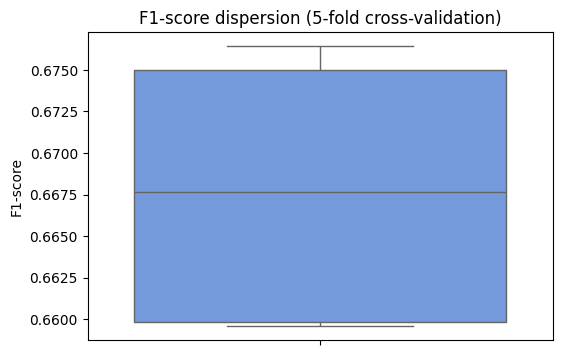

In [3]:
best_model = grid_search.best_estimator_
cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)

print("Scores F1 par pli :", np.round(cv_scores, 4))
print(f"Moyenne : {cv_scores.mean():.4f} | Écart-type : {cv_scores.std():.4f}")

plt.figure(figsize=(6, 4))
sns.boxplot(y=cv_scores, color='cornflowerblue')
plt.title("F1-score dispersion (5-fold cross-validation)")
plt.ylabel("F1-score")
plt.show()

Un faible écart-type entre les plis indique une performance stable et peu dépendante du découpage
des données, ce qui est un bon signe de robustesse avant le passage au jeu de test.

---
## 4. Évaluation sur le jeu de test <a id='section-4'></a>
On évalue le meilleur modèle (issu de la validation croisée) sur le jeu de test, resté totalement à
l'écart de l'entraînement et de l'optimisation des hyperparamètres.

  accuracy : 0.8610
 precision : 0.7774
    recall : 0.5767
        f1 : 0.6622
   roc_auc : 0.9136

              precision    recall  f1-score   support

       <=50K       0.88      0.95      0.91     12435
        >50K       0.78      0.58      0.66      3846

    accuracy                           0.86     16281
   macro avg       0.83      0.76      0.79     16281
weighted avg       0.85      0.86      0.85     16281



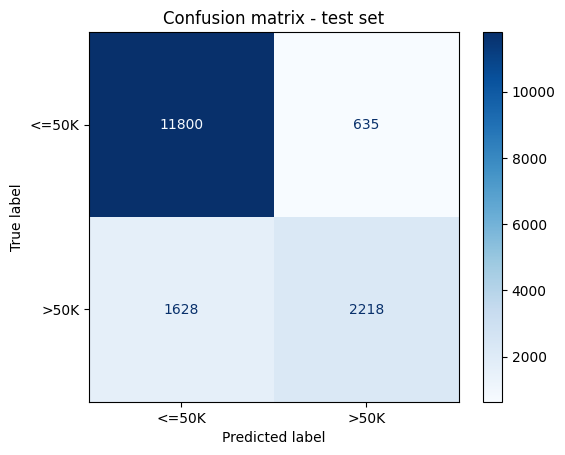

In [4]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

metrics_test = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'roc_auc': roc_auc_score(y_test, y_proba),
}
for k, v in metrics_test.items():
    print(f"{k:>10s} : {v:.4f}")

print()
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['<=50K', '>50K']).plot(cmap='Blues')
plt.title("Confusion matrix - test set")
plt.show()

La matrice de confusion permet de visualiser directement les erreurs du modèle Random Forest sur la
sélection Select K-Best (Phase 3, section 4) : le nombre de faux négatifs (individus `>50K` prédits `<=50K`) est généralement plus
élevé que celui des faux positifs, ce qui reflète le déséquilibre de classe malgré l'optimisation
sur le F1-score. Les métriques ci-dessus serviront de base de comparaison dans le fichier Excel
récapitulatif de la Phase 4.

---
## 5. Analyse de l'overfitting / underfitting <a id='section-5'></a>
On compare la performance du modèle sur le train et sur le test : un écart important indique un
surapprentissage (overfitting), tandis qu'une performance faible des deux côtés indique un
sous-apprentissage (underfitting).

In [5]:
f1_train = f1_score(y_train, best_model.predict(X_train))
f1_test = metrics_test['f1']
gap = f1_train - f1_test

print(f"F1-score (train) : {f1_train:.4f}")
print(f"F1-score (test)  : {f1_test:.4f}")
print(f"Écart train-test : {gap:.4f}")

if gap > 0.08:
    diagnostic = "Overfitting probable (écart train/test important)"
elif f1_train < 0.5 and f1_test < 0.5:
    diagnostic = "Underfitting probable (performance faible sur train ET test)"
else:
    diagnostic = "Pas de signe marqué d'overfitting ni d'underfitting"
print("Diagnostic :", diagnostic)

F1-score (train) : 0.7440
F1-score (test)  : 0.6622
Écart train-test : 0.0819
Diagnostic : Overfitting probable (écart train/test important)


Le diagnostic ci-dessus se base sur l'écart entre F1-score train et test : un écart supérieur à
0.08 est considéré comme révélateur d'un surapprentissage pour ce modèle Random Forest. La validation
croisée et la recherche d'hyperparamètres réalisées en section 3 ont justement pour but de limiter
ce risque en pénalisant les configurations qui collent trop aux données d'entraînement (ex.
profondeur d'arbre trop élevée pour DT/RF, k trop faible pour KNN).

---
## 6. Réflexion originale <a id='section-6'></a>

La sélection Select K-Best, fondée sur un test statistique lié à la cible, tend à produire un bon compromis entre nombre de variables et performance ; il serait intéressant de faire varier K pour observer le point où la performance plafonne.

---
## 7. Questionnements pertinents <a id='section-7'></a>

- Le nombre d'arbres (`n_estimators`) a-t-il encore un effet notable au-delà de 200, ou la performance plafonne-t-elle déjà ?
- L'importance des variables (`feature_importances_`) du modèle confirme-t-elle les variables jugées prédictives en Phase 1, ou révèle-t-elle des interactions inattendues entre variables ?

---
## 8. Sauvegarde des résultats <a id='section-8'></a>
On sauvegarde les métriques de ce modèle dans un fichier CSV partagé, qui sera consolidé dans le
fichier Excel récapitulatif de la Phase 4 (comparaison des 6 combinaisons).

In [6]:
import os

result_row = pd.DataFrame([{
    'combinaison': 'KB_RF',
    'selection': 'KB',
    'modele': 'RF',
    'best_params': str(grid_search.best_params_),
    'f1_cv_train': grid_search.best_score_,
    'f1_train': f1_train,
    'f1_test': f1_test,
    'accuracy_test': metrics_test['accuracy'],
    'precision_test': metrics_test['precision'],
    'recall_test': metrics_test['recall'],
    'roc_auc_test': metrics_test['roc_auc'],
    'overfitting_gap': gap,
    'diagnostic': diagnostic,
}])

results_path = 'model_results.csv'
if os.path.exists(results_path):
    existing = pd.read_csv(results_path)
    existing = existing[existing['combinaison'] != 'KB_RF']
    result_row = pd.concat([existing, result_row], ignore_index=True)
result_row.to_csv(results_path, index=False)
print("Résultats sauvegardés dans model_results.csv")
result_row

Résultats sauvegardés dans model_results.csv


,combinaison,selection,modele,best_params,f1_cv_train,f1_train,f1_test,accuracy_test,precision_test,recall_test,roc_auc_test,overfitting_gap,diagnostic
0,KB_DT,KB,DT,"{'max_depth': None, 'min_samples_leaf': 20}",0.665053,0.701198,0.654870,0.852650,0.733011,0.591784,0.897605,0.046328,Pas de signe marqué d'overfitting ni d'underfi...
1,P_KNN,P,KNN,"{'n_neighbors': 11, 'weights': 'uniform'}",0.645291,0.688615,0.634491,0.840919,0.693827,0.584503,0.882478,0.054124,Pas de signe marqué d'overfitting ni d'underfi...
2,VT_KNN,VT,KNN,"{'n_neighbors': 31, 'weights': 'uniform'}",0.655435,0.679027,0.650502,0.845955,0.700901,0.606864,0.896651,0.028525,Pas de signe marqué d'overfitting ni d'underfi...
3,VT_RF,VT,RF,"{'max_depth': 16, 'n_estimators': 200}",0.677367,0.749837,0.669251,0.863768,0.784615,0.583463,0.915135,0.080586,Overfitting probable (écart train/test important)
4,KB_RF,KB,RF,"{'max_depth': 16, 'n_estimators': 200}",0.667685,0.744045,0.662188,0.861004,0.777427,0.576703,0.913624,0.081857,Overfitting probable (écart train/test important)


Les résultats de la combinaison **KB_RF** sont ajoutés (ou mis à jour) dans `model_results.csv`,
fichier partagé par les 6 notebooks de modélisation et utilisé pour construire le fichier Excel
comparatif final de la Phase 4.